# γ-CKLSearch vs GAUSSSEARCH — scenery embeddings

Same 100 targets, same seeds, real CLIP embeddings. Answers Sir's question about whether γ-CKL "locks in" faster on our actual data.

Assumes the notebook is run from `scenery-search/notebooks/`.

In [1]:
import sys
from pathlib import Path

import numpy as np
from scipy.stats import norm
from collections import defaultdict
from tqdm.auto import tqdm

DATA = Path("../data")
NPZ = DATA / "scenery_embedding.npz"
assert NPZ.exists(), f"embeddings not found at {NPZ}"

data = np.load(NPZ, allow_pickle=True)
E_work = data["E_work"]
paths = np.array([str(p) for p in data["paths"]])
labels = np.array([str(l) for l in data["labels"]])

X_scale = float(E_work.std(axis=0).mean())
X = E_work / X_scale
n, d = X.shape
print(f"X shape: {X.shape}, X_scale: {X_scale:.4f}")
print(f"classes: {sorted(set(labels))}")

X shape: (600, 10), X_scale: 0.1250
classes: [np.str_('buildings'), np.str_('forest'), np.str_('glacier'), np.str_('mountain'), np.str_('sea'), np.str_('street')]


## Algorithms

Both algorithms live inline here so the notebook is self-contained. Copied and lightly cleaned from `search-algorithm/notebooks/01_gamma_ckl_search.ipynb`.

In [2]:
SIGMA_EPS = 0.05


def gamma_ckl_prob(x_i, x_j, x_t, gamma):
    d_i = np.linalg.norm(x_i - x_t)
    d_j = np.linalg.norm(x_j - x_t)
    if d_i == 0: return 1.0
    if d_j == 0: return 0.0
    return (d_j ** gamma) / (d_i ** gamma + d_j ** gamma)


def query_oracle_gckl(x_i, x_j, x_t, gamma, rng):
    p_i = gamma_ckl_prob(x_i, x_j, x_t, gamma)
    return 0 if rng.random() < p_i else 1


def query_oracle_probit(x_i, x_j, x_t, sigma_eps, rng):
    d_i2 = np.sum((x_i - x_t) ** 2)
    d_j2 = np.sum((x_j - x_t) ** 2)
    p_i = norm.cdf((d_j2 - d_i2) / (2 * sigma_eps + 1e-12))
    return 0 if rng.random() < p_i else 1


def sample_mirror_gckl(X, P, used, r=2.0, eps=1e-12):
    mu = (P[:, None] * X).sum(axis=0)
    diff = X - mu
    Sigma = (P[:, None, None] * diff[:, :, None] * diff[:, None, :]).sum(axis=0)
    eigvals, eigvecs = np.linalg.eigh(Sigma)
    lam_max = max(eigvals[-1], eps)
    v_max = eigvecs[:, -1]
    z1 = mu + r * np.sqrt(lam_max) * v_max
    z2 = mu - r * np.sqrt(lam_max) * v_max

    def pick(z, excl):
        d2 = np.sum((X - z) ** 2, axis=1)
        score = d2 / (P + eps)
        for u in excl:
            score[u] = np.inf
        return int(np.argmin(score))

    i = pick(z1, used)
    j = pick(z2, used | {i})
    return i, j


def bayes_update(X, P, i, j, y, gamma, eps=1e-12):
    d_i = np.linalg.norm(X - X[i], axis=1)
    d_j = np.linalg.norm(X - X[j], axis=1)
    d_i_g = d_i ** gamma
    d_j_g = d_j ** gamma
    denom = d_i_g + d_j_g + eps
    if y == i:
        likelihood = d_j_g / denom
    else:
        likelihood = d_i_g / denom
    P_new = P * likelihood
    Z = P_new.sum()
    if Z < eps:
        return P.copy()
    return P_new / Z


def gamma_ckl_search(X, target_idx, gamma, r=2.0, max_queries=200,
                     rng=None, oracle="gckl", sigma_eps=SIGMA_EPS):
    """Answer queries with either γ-CKL or Probit oracle."""
    if rng is None:
        rng = np.random.default_rng()
    n = len(X)
    P = np.ones(n) / n
    used = set()
    x_t = X[target_idx]

    for step in range(max_queries):
        i, j = sample_mirror_gckl(X, P, used, r=r)
        used |= {i, j}
        if oracle == "gckl":
            y_idx = query_oracle_gckl(X[i], X[j], x_t, gamma, rng)
        else:
            y_idx = query_oracle_probit(X[i], X[j], x_t, sigma_eps, rng)
        y = i if y_idx == 0 else j
        if target_idx in (i, j):
            return {"found": True, "n_queries": step + 1}
        P = bayes_update(X, P, i, j, y, gamma)
    return {"found": False, "n_queries": max_queries}


def sample_mirror_gs(mu, Sigma, X, used, eps=1e-12):
    eigvals, eigvecs = np.linalg.eigh(Sigma)
    lam_max = max(eigvals[-1], eps)
    v_max = eigvecs[:, -1]
    z1 = mu + np.sqrt(lam_max) * v_max
    z2 = mu - np.sqrt(lam_max) * v_max

    def nearest(z, excl):
        d2 = np.sum((X - z) ** 2, axis=1)
        for u in excl:
            d2[u] = np.inf
        return int(np.argmin(d2))

    i = nearest(z1, used)
    j = nearest(z2, used | {i})
    return i, j


def adf_update(mu, Sigma, x_i, x_j, y, sigma_eps):
    w = x_j - x_i
    b = 0.5 * (np.dot(x_j, x_j) - np.dot(x_i, x_i))
    sign = -1.0 if y == 0 else 1.0
    v = sign * w
    c = sign * b
    v_Sigma_v = float(v @ Sigma @ v)
    denom = np.sqrt(v_Sigma_v + sigma_eps ** 2)
    z = (v @ mu - c) / denom
    phi = norm.pdf(z)
    Phi = norm.cdf(z)
    if Phi < 1e-12:
        return mu.copy(), Sigma.copy()
    alpha = phi / Phi
    beta = alpha * (alpha + z)
    Sigma_v = Sigma @ v
    mu_new = mu + (alpha / denom) * Sigma_v
    Sigma_new = Sigma - (beta / (v_Sigma_v + sigma_eps ** 2)) * np.outer(Sigma_v, Sigma_v)
    return mu_new, Sigma_new


def gauss_search(X, target_idx, sigma_eps, max_queries=200, rng=None,
                 oracle="probit", gamma=5.0):
    if rng is None:
        rng = np.random.default_rng()
    n, d = X.shape
    mu = np.zeros(d)
    Sigma = np.eye(d)
    used = set()
    x_t = X[target_idx]

    for step in range(max_queries):
        i, j = sample_mirror_gs(mu, Sigma, X, used)
        used |= {i, j}
        if oracle == "probit":
            y = query_oracle_probit(X[i], X[j], x_t, sigma_eps, rng)
        else:
            y = query_oracle_gckl(X[i], X[j], x_t, gamma, rng)
        if target_idx in (i, j):
            return {"found": True, "n_queries": step + 1}
        mu, Sigma = adf_update(mu, Sigma, X[i], X[j], y, sigma_eps)
    return {"found": False, "n_queries": max_queries}

## Pick the 100 targets — reproducible

Same convention as `05_closed_loop_v2.ipynb`.

In [3]:
N_TARGETS = 100
target_rng = np.random.default_rng(seed=12345)
target_indices = target_rng.choice(n, size=N_TARGETS, replace=False)
print(f"picked {len(target_indices)} targets, class distribution:")
from collections import Counter
counts = Counter(labels[target_indices])
for cls in sorted(counts.keys()):
    print(f"  {cls}: {counts[cls]}")

picked 100 targets, class distribution:
  buildings: 13
  forest: 22
  glacier: 13
  mountain: 22
  sea: 16
  street: 14


## Head-to-head — same oracle on both

For each algorithm we test it TWICE: once with its native oracle, once with the other. This shows both:
1. How the algorithms perform in their favored regime
2. How robust each is when the oracle model doesn't match its assumption

In [4]:
def run_all(target_indices, X, gamma_val=5.0, sigma_eps=SIGMA_EPS,
            seed_base=98765, max_queries=200):
    results = defaultdict(list)
    for trial_idx, target in enumerate(tqdm(target_indices)):
        trial_seed = seed_base + trial_idx

        # γ-CKLSearch under both oracles
        r = gamma_ckl_search(X, int(target), gamma=gamma_val, r=2.0,
                              max_queries=max_queries,
                              rng=np.random.default_rng(seed=trial_seed),
                              oracle="gckl", sigma_eps=sigma_eps)
        results["gckl_alg_gckl_oracle"].append(r["n_queries"])

        r = gamma_ckl_search(X, int(target), gamma=gamma_val, r=2.0,
                              max_queries=max_queries,
                              rng=np.random.default_rng(seed=trial_seed),
                              oracle="probit", sigma_eps=sigma_eps)
        results["gckl_alg_probit_oracle"].append(r["n_queries"])

        # GAUSSSEARCH under both oracles
        r = gauss_search(X, int(target), sigma_eps=sigma_eps,
                         max_queries=max_queries,
                         rng=np.random.default_rng(seed=trial_seed),
                         oracle="probit")
        results["gauss_alg_probit_oracle"].append(r["n_queries"])

        r = gauss_search(X, int(target), sigma_eps=sigma_eps,
                         max_queries=max_queries,
                         rng=np.random.default_rng(seed=trial_seed),
                         oracle="gckl", gamma=gamma_val)
        results["gauss_alg_gckl_oracle"].append(r["n_queries"])

    return results


results = run_all(target_indices, X, gamma_val=5.0, sigma_eps=SIGMA_EPS)

print(f"\n{'setup':<28} | {'mean':>6} {'med':>5} {'p90':>5} {'max':>4} {'found%':>7}")
print("-" * 65)
for key in ["gckl_alg_gckl_oracle", "gckl_alg_probit_oracle",
            "gauss_alg_probit_oracle", "gauss_alg_gckl_oracle"]:
    arr = np.array(results[key])
    found_pct = 100 * (arr < 200).sum() / len(arr)
    print(f"{key:<28} | {arr.mean():>6.2f} {np.median(arr):>5.1f} "
          f"{np.percentile(arr, 90):>5.1f} {arr.max():>4d} {found_pct:>6.1f}%")

  0%|          | 0/100 [00:00<?, ?it/s]


setup                        |   mean   med   p90  max  found%
-----------------------------------------------------------------
gckl_alg_gckl_oracle         |  12.83  11.0  21.0   42  100.0%
gckl_alg_probit_oracle       |   8.73   9.0  11.0   16  100.0%
gauss_alg_probit_oracle      |  10.82  11.0  16.0   23  100.0%
gauss_alg_gckl_oracle        |  21.56  16.0  38.3  200   99.0%


### Interpretation

Read the table diagonally:
- **`gckl_alg_gckl_oracle`** vs **`gauss_alg_probit_oracle`** — each algorithm on its native oracle, best-case for both
- **`gckl_alg_probit_oracle`** vs **`gauss_alg_gckl_oracle`** — cross-oracle robustness

If γ-CKL's native performance beats GAUSSSEARCH's native performance on scenery data, that's the win Sir is looking for. If it doesn't, we know GAUSSSEARCH's Gaussian belief handles CLIP embedding geometry better than γ-CKL's item-posterior does.

## γ sweep on scenery — does γ-CKL win in the noisy regime?

In [8]:
gamma_vals = [1.0, 2.0, 3.0, 5.0, 10.0,20]
sweep_results = defaultdict(dict)

for gv in gamma_vals:
    gc_qs = []
    gs_qs = []
    for trial_idx, target in enumerate(target_indices):
        trial_seed = 55555 + int(gv * 1000) + trial_idx
        r = gamma_ckl_search(X, int(target), gamma=gv, r=2.0, max_queries=200,
                              rng=np.random.default_rng(seed=trial_seed),
                              oracle="gckl")
        gc_qs.append(r["n_queries"])
        r = gauss_search(X, int(target), sigma_eps=SIGMA_EPS, max_queries=200,
                         rng=np.random.default_rng(seed=trial_seed),
                         oracle="gckl", gamma=gv)
        gs_qs.append(r["n_queries"])
    sweep_results[gv] = {"gckl": np.array(gc_qs), "gs": np.array(gs_qs)}

print(f"{'γ':>4} | {'γ-CKL mean':>10} {'GAUSS mean':>10} | {'ratio':>6}")
print("-" * 45)
for gv in gamma_vals:
    gc_m = sweep_results[gv]["gckl"].mean()
    gs_m = sweep_results[gv]["gs"].mean()
    print(f"{gv:>4.1f} | {gc_m:>10.2f} {gs_m:>10.2f} | {gc_m/gs_m:>6.2f}")

   γ | γ-CKL mean GAUSS mean |  ratio
---------------------------------------------
 1.0 |      62.68     103.65 |   0.60
 2.0 |      31.66      55.40 |   0.57
 3.0 |      19.42      38.82 |   0.50
 5.0 |      12.70      27.85 |   0.46
10.0 |       9.59      13.69 |   0.70
20.0 |       8.81      11.78 |   0.75


### Interpretation

Both algorithms answered with the same γ-CKL oracle here. Lower γ = noisier oracle.

If the ratio is < 1 at low γ, that confirms the paper's claim: γ-CKL is more robust to oracle noise. If not, then on our CLIP scenery embeddings there's no win regardless of noise level.

## Save results

For downstream analysis and the writeup.

In [9]:
import pickle

out_path = Path("../data/gamma_ckl_scenery_results.pkl")
with out_path.open("wb") as f:
    pickle.dump({
        "results": dict(results),
        "sweep_results": {k: dict(v) for k, v in sweep_results.items()},
        "target_indices": target_indices.tolist(),
        "n": n, "d": d, "X_scale": X_scale,
        "sigma_eps": SIGMA_EPS,
    }, f)
print(f"saved to {out_path}")

saved to ..\data\gamma_ckl_scenery_results.pkl


In [10]:
from collections import defaultdict as dd

by_class = {"gckl": dd(list), "gs": dd(list)}
for trial_idx, target in enumerate(target_indices):
    cls = labels[target]
    by_class["gckl"][cls].append(results["gckl_alg_gckl_oracle"][trial_idx])
    by_class["gs"][cls].append(results["gauss_alg_gckl_oracle"][trial_idx])

print(f"{'class':<12} | {'γ-CKL mean':>10} {'GAUSS mean':>10} | {'ratio':>6}")
print("-" * 50)
for cls in sorted(by_class["gckl"].keys()):
    gc = np.mean(by_class["gckl"][cls])
    gs = np.mean(by_class["gs"][cls])
    print(f"{cls:<12} | {gc:>10.2f} {gs:>10.2f} | {gc/gs:>6.2f}")

class        | γ-CKL mean GAUSS mean |  ratio
--------------------------------------------------
buildings    |      15.38      35.38 |   0.43
forest       |      12.77      18.45 |   0.69
glacier      |       9.69      23.92 |   0.41
mountain     |      15.27      15.50 |   0.99
sea          |      11.06      21.69 |   0.51
street       |      11.64      20.79 |   0.56


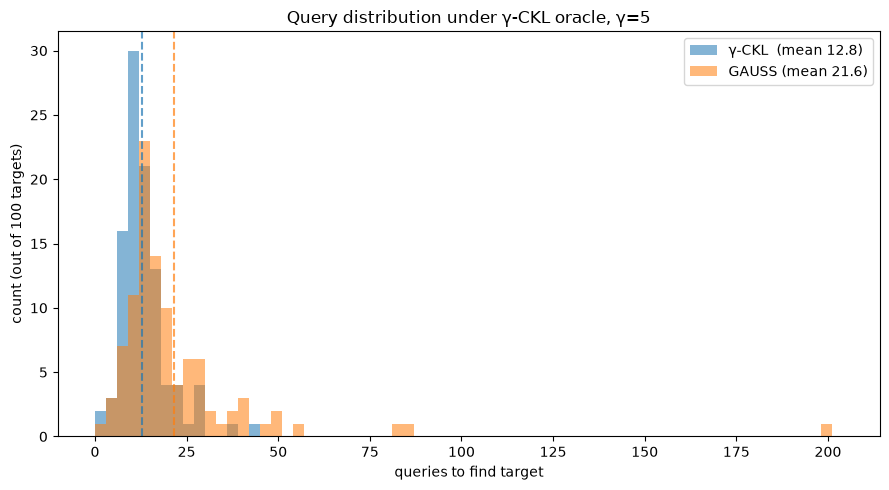

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
gc = np.array(results["gckl_alg_gckl_oracle"])
gs = np.array(results["gauss_alg_gckl_oracle"])

bins = np.arange(0, max(gc.max(), gs.max()) + 5, 3)
ax.hist(gc, bins=bins, alpha=0.55, label=f"γ-CKL  (mean {gc.mean():.1f})", color="tab:blue")
ax.hist(gs, bins=bins, alpha=0.55, label=f"GAUSS (mean {gs.mean():.1f})", color="tab:orange")
ax.axvline(gc.mean(), color="tab:blue", ls="--", alpha=0.7)
ax.axvline(gs.mean(), color="tab:orange", ls="--", alpha=0.7)
ax.set_xlabel("queries to find target")
ax.set_ylabel("count (out of 100 targets)")
ax.set_title("Query distribution under γ-CKL oracle, γ=5")
ax.legend()
plt.tight_layout()
plt.show()

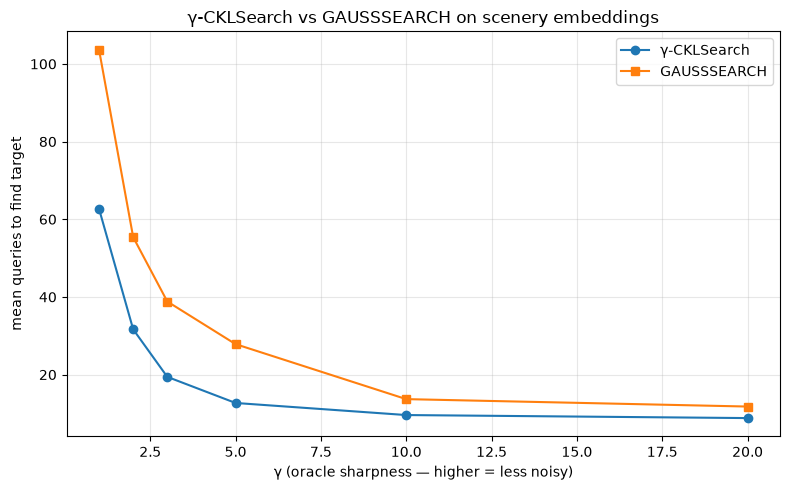

In [12]:
import matplotlib.pyplot as plt

gvs = sorted(sweep_results.keys())
gc_means = [sweep_results[gv]["gckl"].mean() for gv in gvs]
gs_means = [sweep_results[gv]["gs"].mean() for gv in gvs]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gvs, gc_means, "o-", label="γ-CKLSearch", color="tab:blue")
ax.plot(gvs, gs_means, "s-", label="GAUSSSEARCH", color="tab:orange")
ax.set_xlabel("γ (oracle sharpness — higher = less noisy)")
ax.set_ylabel("mean queries to find target")
ax.set_title("γ-CKLSearch vs GAUSSSEARCH on scenery embeddings")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
import matplotlib.pyplot as plt

def gamma_ckl_search_traced(X, target_idx, gamma, r=2.0, max_queries=50, rng=None):
    """Same as gamma_ckl_search but records the full trajectory."""
    if rng is None:
        rng = np.random.default_rng()
    n = len(X)
    P = np.ones(n) / n
    used = set()
    x_t = X[target_idx]
    trace = []

    for step in range(max_queries):
        i, j = sample_mirror_gckl(X, P, used, r=r)
        used |= {i, j}
        y_idx = query_oracle_gckl(X[i], X[j], x_t, gamma, rng)
        y = i if y_idx == 0 else j
        argmax = int(np.argmax(P))
        trace.append({
            "step": step,
            "i": i, "j": j,
            "label_i": labels[i], "label_j": labels[j],
            "picked": "A" if y == i else "B",
            "picked_idx": y,
            "picked_label": labels[y],
            "P_target": float(P[target_idx]),
            "argmax": argmax,
            "argmax_label": labels[argmax],
            "target_in_query": target_idx in (i, j),
        })
        if target_idx in (i, j):
            return {"found": True, "n_queries": step + 1, "trace": trace}
        P = bayes_update(X, P, i, j, y, gamma)
    return {"found": False, "n_queries": max_queries, "trace": trace}


# One target per class (first target of each class from target_indices)
picked_per_class = {}
for idx in target_indices:
    cls = labels[idx]
    if cls not in picked_per_class:
        picked_per_class[cls] = int(idx)

print(f"Tracing one search per class (γ=5, γ-CKL oracle):\n")

traces = {}
for cls in sorted(picked_per_class.keys()):
    target = picked_per_class[cls]
    res = gamma_ckl_search_traced(
        X, target, gamma=5.0, r=2.0, max_queries=50,
        rng=np.random.default_rng(seed=12345 + target),
    )
    traces[cls] = res
    print(f"=== class '{cls}' (target idx {target}) ===")
    print(f"    found in {res['n_queries']} queries" if res['found']
          else f"    NOT found in {res['n_queries']} queries")
    for step_rec in res["trace"]:
        marker = "  <-- TARGET IN QUERY" if step_rec["target_in_query"] else ""
        lock = " ✓" if step_rec["argmax_label"] == cls else ""
        print(f"    step {step_rec['step']:2d}: "
              f"A={step_rec['label_i']:<10} B={step_rec['label_j']:<10} "
              f"picked {step_rec['picked']}={step_rec['picked_label']:<10} "
              f"| P[target]={step_rec['P_target']:.4f} "
              f"argmax={step_rec['argmax_label']:<10}{lock}{marker}")
    print()

Tracing one search per class (γ=5, γ-CKL oracle):

=== class 'buildings' (target idx 38) ===
    found in 6 queries
    step  0: A=mountain   B=buildings  picked B=buildings  | P[target]=0.0017 argmax=buildings  ✓
    step  1: A=forest     B=buildings  picked B=buildings  | P[target]=0.0031 argmax=buildings  ✓
    step  2: A=buildings  B=street     picked A=buildings  | P[target]=0.0049 argmax=street    
    step  3: A=buildings  B=street     picked A=buildings  | P[target]=0.0128 argmax=buildings  ✓
    step  4: A=buildings  B=buildings  picked B=buildings  | P[target]=0.0242 argmax=buildings  ✓
    step  5: A=buildings  B=buildings  picked B=buildings  | P[target]=0.0436 argmax=buildings  ✓  <-- TARGET IN QUERY

=== class 'forest' (target idx 114) ===
    found in 10 queries
    step  0: A=mountain   B=buildings  picked A=mountain   | P[target]=0.0017 argmax=buildings 
    step  1: A=glacier    B=forest     picked B=forest     | P[target]=0.0027 argmax=mountain  
    step  2: A=fores

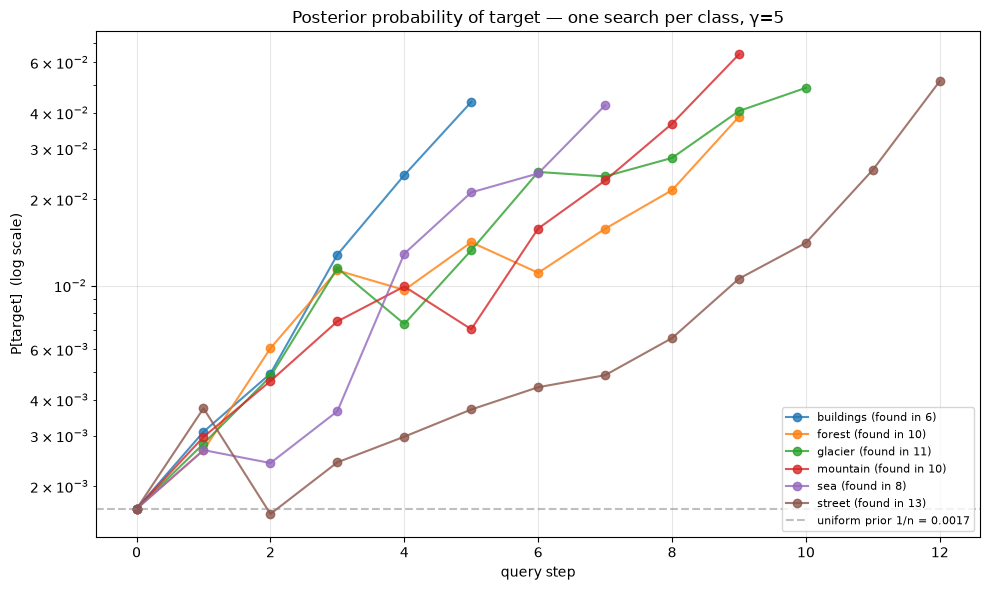

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
for cls in sorted(traces.keys()):
    trace = traces[cls]["trace"]
    steps = [t["step"] for t in trace]
    p_target = [t["P_target"] for t in trace]
    n_q = traces[cls]["n_queries"]
    ax.plot(steps, p_target, "o-", label=f"{cls} (found in {n_q})", alpha=0.8)

ax.axhline(1/n, color="gray", ls="--", alpha=0.5, label=f"uniform prior 1/n = {1/n:.4f}")
ax.set_yscale("log")
ax.set_xlabel("query step")
ax.set_ylabel("P[target]  (log scale)")
ax.set_title("Posterior probability of target — one search per class, γ=5")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

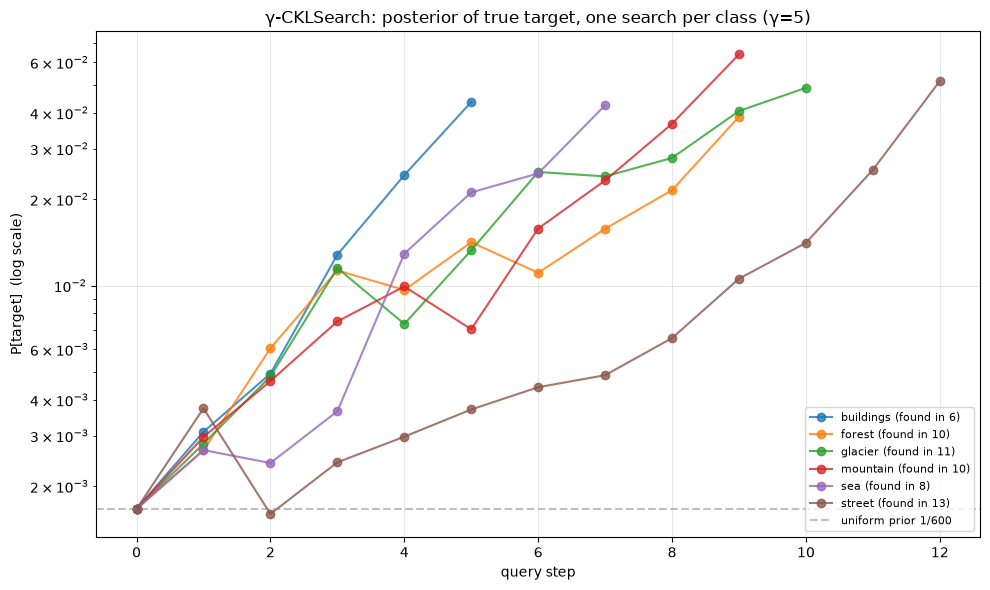

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
for cls in sorted(traces.keys()):
    trace = traces[cls]["trace"]
    steps = [t["step"] for t in trace]
    p_target = [t["P_target"] for t in trace]
    n_q = traces[cls]["n_queries"]
    ax.plot(steps, p_target, "o-", label=f"{cls} (found in {n_q})", alpha=0.8)

ax.axhline(1/n, color="gray", ls="--", alpha=0.5, label=f"uniform prior 1/{n}")
ax.set_yscale("log")
ax.set_xlabel("query step")
ax.set_ylabel("P[target]  (log scale)")
ax.set_title("γ-CKLSearch: posterior of true target, one search per class (γ=5)")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../data/gamma_ckl_convergence_per_class.png", dpi=120, bbox_inches="tight")
plt.show()